In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available")

CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q diffusers transformers accelerate safetensors

In [3]:
from diffusers import StableDiffusionPipeline
import torch

# Check GPU
if not torch.cuda.is_available():
    raise RuntimeError("GPU is not available. Enable GPU in Runtime > Change runtime type.")

# Load Stable Diffusion model
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

# Move model to GPU
pipe = pipe.to("cuda")

# Prompt
prompt = "A futuristic city skyline at sunset, digital art, highly detailed"

# Generate image
image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# Save image
image.save("generated_city.png")

print("Image generated and saved as generated_city.png")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Image generated and saved as generated_city.png


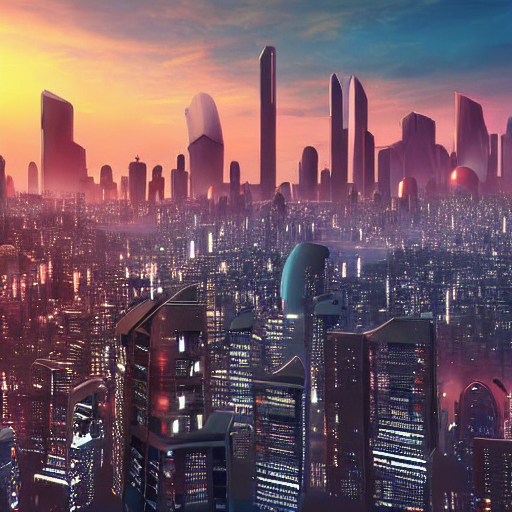

In [4]:
from IPython.display import display

display(image)